## Imports and Data Cleaning

In [1]:
import firebase_admin
from firebase_admin import credentials, firestore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if not firebase_admin._apps:
    cred = credentials.Certificate("firebase-key.json")
    firebase_admin.initialize_app(cred)

db = firestore.client()

print("Fetching sessions...")
sessions_ref = db.collection("test_sessions")
docs = sessions_ref.stream()

session_data = []
for doc in docs:
    data = doc.to_dict()
    data['userId'] = doc.id
    session_data.append(data)

df_sessions = pd.json_normalize(session_data)

print(f"Successfully loaded {len(df_sessions)} sessions.")

Fetching sessions...
Successfully loaded 73 sessions.


In [2]:
print("Fetching ALL response data...")

all_data = []
user_count = 0

users_ref = db.collection("test_sessions").stream()
for user in users_ref:
    user_count += 1
    user_id = user.id
    
    responses_ref = db.collection("test_sessions").document(user_id).collection("responses").stream()
    for response in responses_ref:
        resp_dict = response.to_dict()
        time_taken_sec = resp_dict.get('timeTakenMs', 0) / 1000.0
        all_data.append({
            'userId': user_id,
            'questionNumber': resp_dict.get('questionNumber'),
            'isCorrect': resp_dict.get('isCorrect', False),
            'userAnswer': resp_dict.get('userAnswer'),
            'timeTakenSec': time_taken_sec,
            'style': resp_dict.get('style')
        })

df_all_raw = pd.DataFrame(all_data)
print(f"Successfully extracted {len(df_all_raw)} total raw responses, from {user_count} users.")

# Remove massive 500+ sec anomalies
df_base = df_all_raw[df_all_raw['timeTakenSec'] <= 300].copy()

df_shaded_base = df_base[df_base['style'] == 'shaded'].copy()
df_lined_base = df_base[df_base['style'] == 'lined'].copy()

# --- SHADED Processing ---
df_shaded_time = df_shaded_base[df_shaded_base['userAnswer'] != 'SKIPPED'].copy()
df_shaded_score = df_shaded_base.copy()
df_shaded_score.loc[df_shaded_score['userAnswer'] == 'SKIPPED', 'isCorrect'] = False
df_shaded_score['isCorrect'] = df_shaded_score['isCorrect'].astype(bool)

df_shaded_avg_time = df_shaded_time.groupby('questionNumber')['timeTakenSec'].mean().reset_index()
df_shaded_avg_time = df_shaded_avg_time.sort_values(by='questionNumber')

# --- LINED Processing ---
df_lined_time = df_lined_base[df_lined_base['userAnswer'] != 'SKIPPED'].copy()
df_lined_score = df_lined_base.copy()
df_lined_score.loc[df_lined_score['userAnswer'] == 'SKIPPED', 'isCorrect'] = False
df_lined_score['isCorrect'] = df_lined_score['isCorrect'].astype(bool)

df_lined_avg_time = df_lined_time.groupby('questionNumber')['timeTakenSec'].mean().reset_index()
df_lined_avg_time = df_lined_avg_time.sort_values(by='questionNumber')

print("\n--- DATA READY ---")
print(f"Shaded - Used for Time: {len(df_shaded_time)} | Used for Score: {len(df_shaded_score)}")
print(f"Lined  - Used for Time: {len(df_lined_time)} | Used for Score: {len(df_lined_score)}")

Fetching ALL response data...
Successfully extracted 1812 total raw responses, from 73 users.

--- DATA READY ---
Shaded - Used for Time: 867 | Used for Score: 895
Lined  - Used for Time: 879 | Used for Score: 903


## Shaded Data

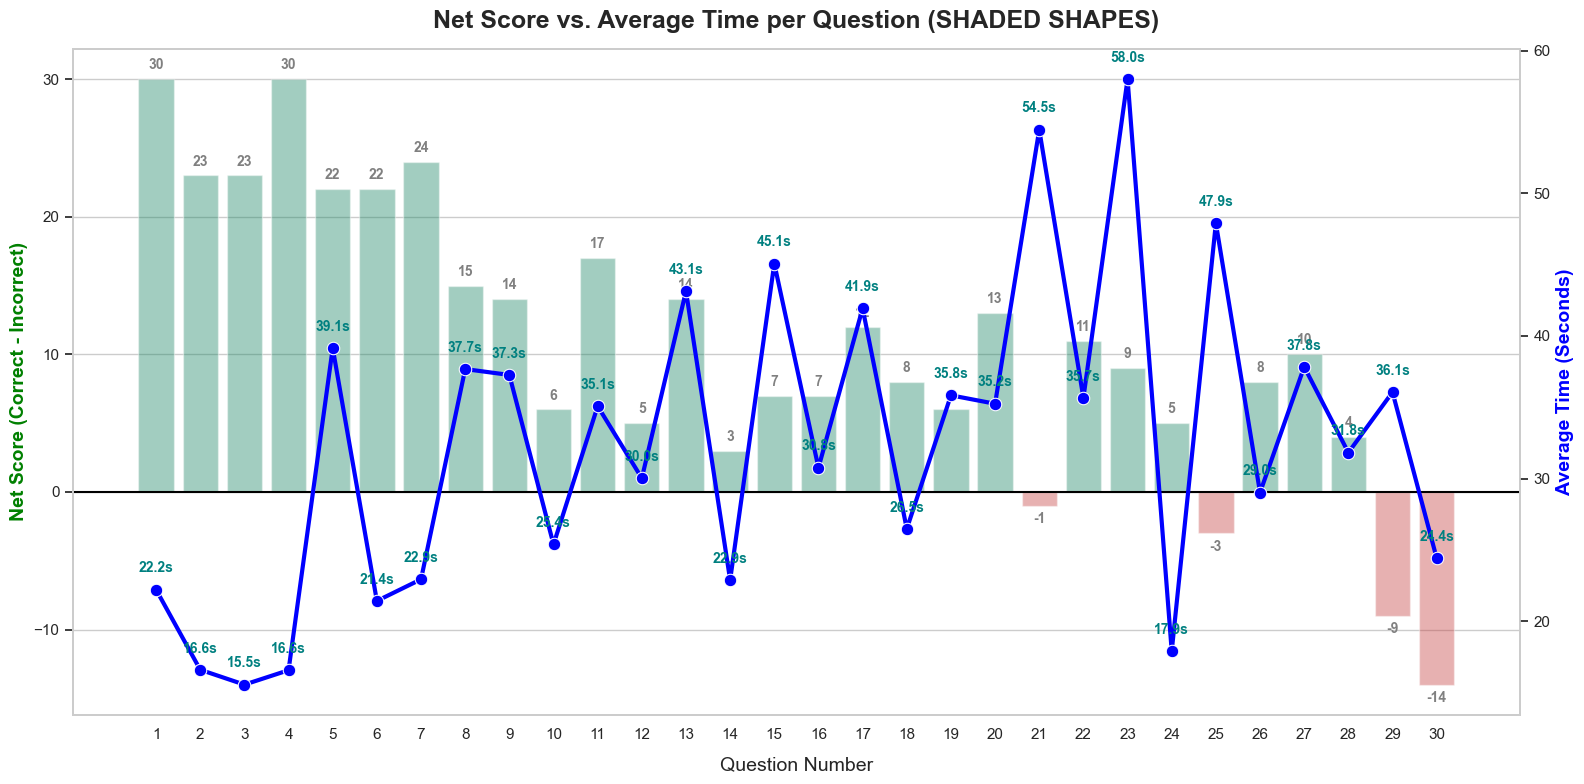

In [3]:
df_shaded_score['score_weight'] = np.where(df_shaded_score['isCorrect'] == True, 1, -1)
df_net_score_shaded = df_shaded_score.groupby('questionNumber')['score_weight'].sum().reset_index()

df_combined_shaded = pd.merge(df_shaded_avg_time, df_net_score_shaded, on='questionNumber')
df_combined_shaded = df_combined_shaded.sort_values('questionNumber').reset_index(drop=True)

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- AXIS 1: Bar Chart (Net Score) ---
bar_colors = np.where(df_combined_shaded['score_weight'] >= 0, '#059669', '#dc2626').tolist()

sns.barplot(
    data=df_combined_shaded,
    x='questionNumber',
    y='score_weight',
    hue='questionNumber',
    palette=bar_colors,
    alpha=0.4,
    ax=ax1,
    legend=False
)

ax1.set_ylabel("Net Score (Correct - Incorrect)", fontsize=14, fontweight='bold', color='green')
ax1.set_xlabel("Question Number", fontsize=14, labelpad=10)
ax1.axhline(0, color='black', linewidth=1.5)

for index, row in df_combined_shaded.iterrows():
    y_val = row['score_weight']
    offset = 0.5 if y_val >= 0 else -1.5
    ax1.text(index, y_val + offset, f"{int(y_val)}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='grey')

# --- AXIS 2: Line Chart (Average Time) ---
ax2 = ax1.twinx()

sns.lineplot(
    data=df_combined_shaded, 
    x=df_combined_shaded.index, 
    y='timeTakenSec', 
    marker='o', 
    linewidth=3, 
    markersize=9,
    color='blue',
    ax=ax2
)

ax2.set_ylabel("Average Time (Seconds)", fontsize=14, fontweight='bold', color='blue')
ax2.grid(False)

for index, row in df_combined_shaded.iterrows():
    ax2.text(index, row['timeTakenSec'] + 1, 
             f"{row['timeTakenSec']:.1f}s", 
             ha='center', va='bottom', fontsize=10, color='teal', fontweight='bold')

plt.title("Net Score vs. Average Time per Question (SHADED SHAPES)", fontsize=18, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [4]:
# --- TIMING METRICS (SHADED) ---
df_avg_sorted_shaded = df_shaded_avg_time.sort_values(by='timeTakenSec').reset_index(drop=True)
shortest_q_s = df_avg_sorted_shaded.iloc[0]
longest_q_s = df_avg_sorted_shaded.iloc[-1]
middle_idx_s = len(df_avg_sorted_shaded) // 2
middle_q_s = df_avg_sorted_shaded.iloc[middle_idx_s]

print("--- TIMING METRICS: SHADED (Excludes Skips) ---")
print(f"FASTEST Question: Q{int(shortest_q_s['questionNumber'])} ({shortest_q_s['timeTakenSec']:.1f} seconds)")
print(f"MIDDLE Question:  Q{int(middle_q_s['questionNumber'])} ({middle_q_s['timeTakenSec']:.1f} seconds)")
print(f"SLOWEST Question: Q{int(longest_q_s['questionNumber'])} ({longest_q_s['timeTakenSec']:.1f} seconds)\n")

# --- SCORING METRICS (SHADED) ---
df_accuracy_shaded = df_shaded_score.groupby('questionNumber')['isCorrect'].mean().reset_index()
df_accuracy_shaded['accuracy_pct'] = df_accuracy_shaded['isCorrect'] * 100

df_acc_sorted_shaded = df_accuracy_shaded.sort_values(by='accuracy_pct').reset_index(drop=True)

min_acc_s = df_acc_sorted_shaded['accuracy_pct'].min()
max_acc_s = df_acc_sorted_shaded['accuracy_pct'].max()

mid_idx_s = len(df_acc_sorted_shaded) // 2
mid_acc_s = df_acc_sorted_shaded.iloc[mid_idx_s]['accuracy_pct']

least_qs_s = df_acc_sorted_shaded[df_acc_sorted_shaded['accuracy_pct'] == min_acc_s]['questionNumber'].tolist()
most_qs_s = df_acc_sorted_shaded[df_acc_sorted_shaded['accuracy_pct'] == max_acc_s]['questionNumber'].tolist()
middle_qs_s = df_acc_sorted_shaded[df_acc_sorted_shaded['accuracy_pct'] == mid_acc_s]['questionNumber'].tolist()

def format_qs(q_list):
    return ", ".join([f"Q{int(q)}" for q in q_list])

print("--- SCORING METRICS: SHADED (Skips = Incorrect) ---")
print(f"MOST Correctly Answered:   {format_qs(most_qs_s)} ({max_acc_s:.1f}% accuracy)")
print(f"MIDDLE Correctly Answered: {format_qs(middle_qs_s)} ({mid_acc_s:.1f}% accuracy)")
print(f"LEAST Correctly Answered:  {format_qs(least_qs_s)} ({min_acc_s:.1f}% accuracy)")

--- TIMING METRICS: SHADED (Excludes Skips) ---
FASTEST Question: Q3 (15.5 seconds)
MIDDLE Question:  Q11 (35.1 seconds)
SLOWEST Question: Q23 (58.0 seconds)

--- SCORING METRICS: SHADED (Skips = Incorrect) ---
MOST Correctly Answered:   Q1 (94.1% accuracy)
MIDDLE Correctly Answered: Q27 (67.9% accuracy)
LEAST Correctly Answered:  Q30 (23.1% accuracy)


In [5]:
df_shaded_score['is_skipped'] = df_shaded_score['userAnswer'] == 'SKIPPED'
df_shaded_score['is_actual_incorrect'] = (~df_shaded_score['isCorrect']) & (~df_shaded_score['is_skipped'])

df_summary_shaded = df_shaded_score.groupby('questionNumber').agg(
    Total_Answers=('isCorrect', 'count'),
    Correct_Answers=('isCorrect', 'sum'),
    Incorrect_Answers=('is_actual_incorrect', 'sum'),
    Skipped_Answers=('is_skipped', 'sum')
).reset_index()

df_time_metrics_shaded = df_shaded_score[~df_shaded_score['is_skipped']].groupby('questionNumber').agg(
    Avg_Time_Sec=('timeTakenSec', 'mean')
).reset_index()

df_summary_shaded = pd.merge(df_summary_shaded, df_time_metrics_shaded, on='questionNumber', how='left')

df_summary_shaded['Net_Score'] = df_summary_shaded['Correct_Answers'] - df_summary_shaded['Incorrect_Answers'] - df_summary_shaded['Skipped_Answers']
df_summary_shaded['Accuracy_Pct'] = (df_summary_shaded['Correct_Answers'] / df_summary_shaded['Total_Answers']) * 100

df_summary_shaded['Accuracy_Pct'] = df_summary_shaded['Accuracy_Pct'].round(1)
df_summary_shaded['Avg_Time_Sec'] = df_summary_shaded['Avg_Time_Sec'].round(1)

df_summary_sorted_shaded = df_summary_shaded.sort_values(by=['questionNumber'], ascending=[True]).reset_index(drop=True)

print("--- RAW TALLY (SHADED) ---")
print(df_summary_sorted_shaded.to_string(index=False))

grand_avg_time_s = df_summary_sorted_shaded['Avg_Time_Sec'].mean()
print(f"\nGRAND AVERAGE (SHADED): {grand_avg_time_s:.1f} seconds per question")

max_net_s = df_summary_sorted_shaded['Net_Score'].max()
min_net_s = df_summary_sorted_shaded['Net_Score'].min()

df_by_net_s = df_summary_sorted_shaded.sort_values(by='Net_Score').reset_index(drop=True)
mid_net_s = df_by_net_s.iloc[len(df_by_net_s) // 2]['Net_Score']

best_qs_s = df_summary_sorted_shaded[df_summary_sorted_shaded['Net_Score'] == max_net_s]['questionNumber'].tolist()
worst_qs_s = df_summary_sorted_shaded[df_summary_sorted_shaded['Net_Score'] == min_net_s]['questionNumber'].tolist()
mid_qs_s = df_summary_sorted_shaded[df_summary_sorted_shaded['Net_Score'] == mid_net_s]['questionNumber'].tolist()

print("\n--- RANKED BY NET SCORE (SHADED) ---")
print(f"BEST Performing:   {format_qs(best_qs_s)} (Net Score: {max_net_s})")
print(f"MIDDLE Performing: {format_qs(mid_qs_s)} (Net Score: {mid_net_s})")
print(f"WORST Performing:  {format_qs(worst_qs_s)} (Net Score: {min_net_s})")

--- RAW TALLY (SHADED) ---
 questionNumber  Total_Answers  Correct_Answers  Incorrect_Answers  Skipped_Answers  Avg_Time_Sec  Net_Score  Accuracy_Pct
              1             34               32                  2                0          22.2         30          94.1
              2             37               30                  5                2          16.6         23          81.1
              3             31               27                  4                0          15.5         23          87.1
              4             36               33                  3                0          16.6         30          91.7
              5             32               27                  5                0          39.1         22          84.4
              6             34               28                  5                1          21.4         22          82.4
              7             32               28                  4                0          22.9         24    

## Lined Data

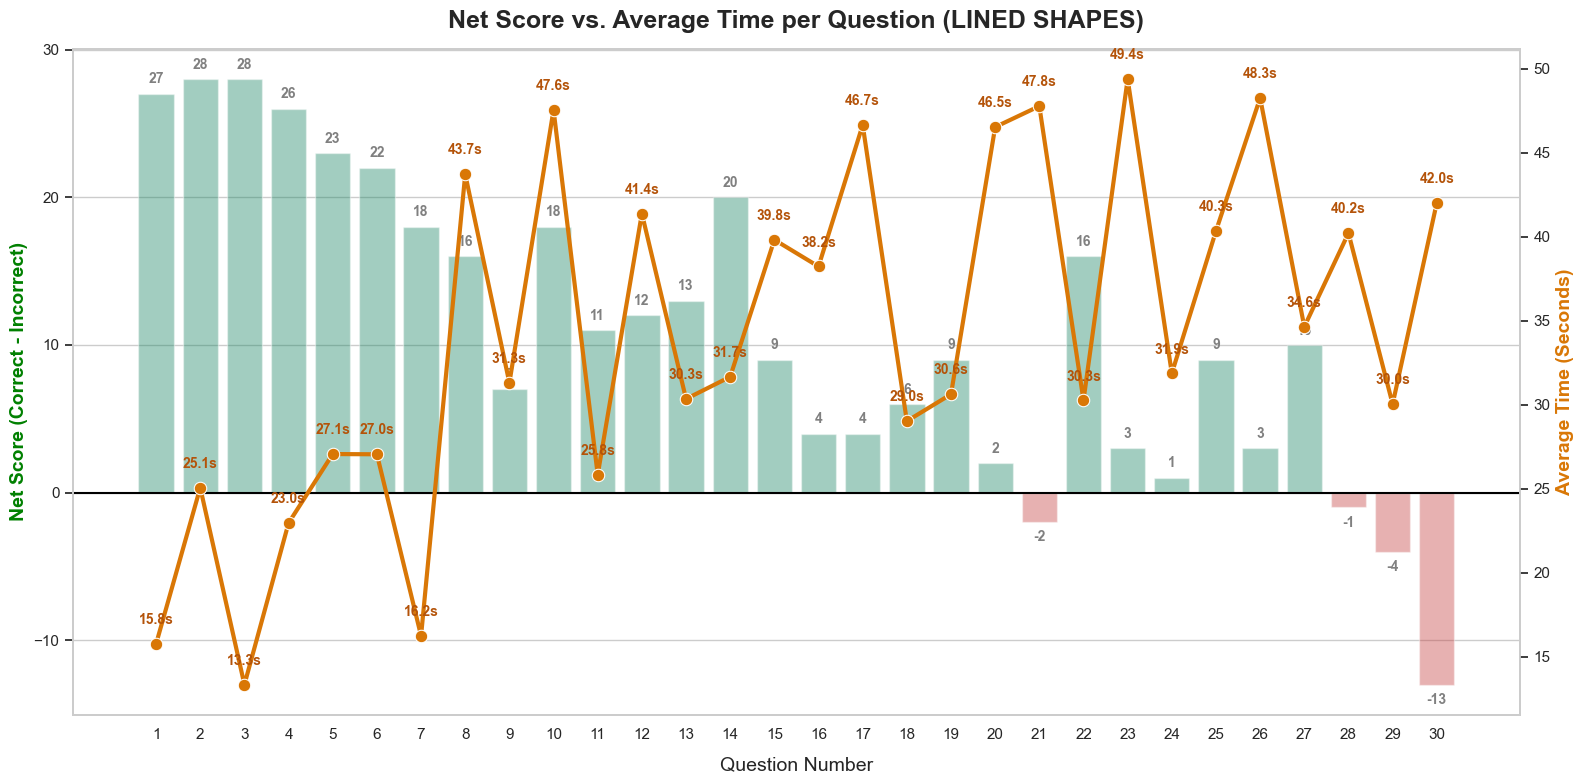

In [6]:
df_lined_score['score_weight'] = np.where(df_lined_score['isCorrect'] == True, 1, -1)
df_net_score_lined = df_lined_score.groupby('questionNumber')['score_weight'].sum().reset_index()

df_combined_lined = pd.merge(df_lined_avg_time, df_net_score_lined, on='questionNumber')
df_combined_lined = df_combined_lined.sort_values('questionNumber').reset_index(drop=True)

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- AXIS 1: Bar Chart (Net Score) ---
bar_colors_lined = np.where(df_combined_lined['score_weight'] >= 0, '#059669', '#dc2626').tolist()

sns.barplot(
    data=df_combined_lined,
    x='questionNumber',
    y='score_weight',
    hue='questionNumber',
    palette=bar_colors_lined,
    alpha=0.4,
    ax=ax1,
    legend=False
)

ax1.set_ylabel("Net Score (Correct - Incorrect)", fontsize=14, fontweight='bold', color='green')
ax1.set_xlabel("Question Number", fontsize=14, labelpad=10)
ax1.axhline(0, color='black', linewidth=1.5)

for index, row in df_combined_lined.iterrows():
    y_val = row['score_weight']
    offset = 0.5 if y_val >= 0 else -1.5
    ax1.text(index, y_val + offset, f"{int(y_val)}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='grey')

# --- AXIS 2: Line Chart (Average Time) ---
ax2 = ax1.twinx()

sns.lineplot(
    data=df_combined_lined, 
    x=df_combined_lined.index, 
    y='timeTakenSec', 
    marker='o', 
    linewidth=3, 
    markersize=9,
    color='#d97706',
    ax=ax2
)

ax2.set_ylabel("Average Time (Seconds)", fontsize=14, fontweight='bold', color='#d97706')
ax2.grid(False)

for index, row in df_combined_lined.iterrows():
    ax2.text(index, row['timeTakenSec'] + 1, 
             f"{row['timeTakenSec']:.1f}s", 
             ha='center', va='bottom', fontsize=10, color='#b45309', fontweight='bold')

plt.title("Net Score vs. Average Time per Question (LINED SHAPES)", fontsize=18, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [7]:
# --- TIMING METRICS (LINED) ---
df_avg_sorted_lined = df_lined_avg_time.sort_values(by='timeTakenSec').reset_index(drop=True)
shortest_q_l = df_avg_sorted_lined.iloc[0]
longest_q_l = df_avg_sorted_lined.iloc[-1]
middle_idx_l = len(df_avg_sorted_lined) // 2
middle_q_l = df_avg_sorted_lined.iloc[middle_idx_l]

print("--- TIMING METRICS: LINED (Excludes Skips) ---")
print(f"FASTEST Question: Q{int(shortest_q_l['questionNumber'])} ({shortest_q_l['timeTakenSec']:.1f} seconds)")
print(f"MIDDLE Question:  Q{int(middle_q_l['questionNumber'])} ({middle_q_l['timeTakenSec']:.1f} seconds)")
print(f"SLOWEST Question: Q{int(longest_q_l['questionNumber'])} ({longest_q_l['timeTakenSec']:.1f} seconds)\n")

# --- SCORING METRICS (LINED) ---
df_accuracy_lined = df_lined_score.groupby('questionNumber')['isCorrect'].mean().reset_index()
df_accuracy_lined['accuracy_pct'] = df_accuracy_lined['isCorrect'] * 100

df_acc_sorted_lined = df_accuracy_lined.sort_values(by='accuracy_pct').reset_index(drop=True)

min_acc_l = df_acc_sorted_lined['accuracy_pct'].min()
max_acc_l = df_acc_sorted_lined['accuracy_pct'].max()

mid_idx_l = len(df_acc_sorted_lined) // 2
mid_acc_l = df_acc_sorted_lined.iloc[mid_idx_l]['accuracy_pct']

least_qs_l = df_acc_sorted_lined[df_acc_sorted_lined['accuracy_pct'] == min_acc_l]['questionNumber'].tolist()
most_qs_l = df_acc_sorted_lined[df_acc_sorted_lined['accuracy_pct'] == max_acc_l]['questionNumber'].tolist()
middle_qs_l = df_acc_sorted_lined[df_acc_sorted_lined['accuracy_pct'] == mid_acc_l]['questionNumber'].tolist()

print("--- SCORING METRICS: LINED (Skips = Incorrect) ---")
print(f"MOST Correctly Answered:   {format_qs(most_qs_l)} ({max_acc_l:.1f}% accuracy)")
print(f"MIDDLE Correctly Answered: {format_qs(middle_qs_l)} ({mid_acc_l:.1f}% accuracy)")
print(f"LEAST Correctly Answered:  {format_qs(least_qs_l)} ({min_acc_l:.1f}% accuracy)")

--- TIMING METRICS: LINED (Excludes Skips) ---
FASTEST Question: Q3 (13.3 seconds)
MIDDLE Question:  Q24 (31.9 seconds)
SLOWEST Question: Q23 (49.4 seconds)

--- SCORING METRICS: LINED (Skips = Incorrect) ---
MOST Correctly Answered:   Q2 (91.2% accuracy)
MIDDLE Correctly Answered: Q11 (67.7% accuracy)
LEAST Correctly Answered:  Q30 (27.6% accuracy)


In [8]:
df_lined_score['is_skipped'] = df_lined_score['userAnswer'] == 'SKIPPED'
df_lined_score['is_actual_incorrect'] = (~df_lined_score['isCorrect']) & (~df_lined_score['is_skipped'])

df_summary_lined = df_lined_score.groupby('questionNumber').agg(
    Total_Answers=('isCorrect', 'count'),
    Correct_Answers=('isCorrect', 'sum'),
    Incorrect_Answers=('is_actual_incorrect', 'sum'),
    Skipped_Answers=('is_skipped', 'sum')
).reset_index()

df_time_metrics_lined = df_lined_score[~df_lined_score['is_skipped']].groupby('questionNumber').agg(
    Avg_Time_Sec=('timeTakenSec', 'mean')
).reset_index()

df_summary_lined = pd.merge(df_summary_lined, df_time_metrics_lined, on='questionNumber', how='left')

df_summary_lined['Net_Score'] = df_summary_lined['Correct_Answers'] - df_summary_lined['Incorrect_Answers'] - df_summary_lined['Skipped_Answers']
df_summary_lined['Accuracy_Pct'] = (df_summary_lined['Correct_Answers'] / df_summary_lined['Total_Answers']) * 100

df_summary_lined['Accuracy_Pct'] = df_summary_lined['Accuracy_Pct'].round(1)
df_summary_lined['Avg_Time_Sec'] = df_summary_lined['Avg_Time_Sec'].round(1)

df_summary_sorted_lined = df_summary_lined.sort_values(by=['questionNumber'], ascending=[True]).reset_index(drop=True)

print("--- RAW TALLY (LINED) ---")
print(df_summary_sorted_lined.to_string(index=False))

grand_avg_time_l = df_summary_sorted_lined['Avg_Time_Sec'].mean()
print(f"\nGRAND AVERAGE (LINED): {grand_avg_time_l:.1f} seconds per question")

max_net_l = df_summary_sorted_lined['Net_Score'].max()
min_net_l = df_summary_sorted_lined['Net_Score'].min()

df_by_net_l = df_summary_sorted_lined.sort_values(by='Net_Score').reset_index(drop=True)
mid_net_l = df_by_net_l.iloc[len(df_by_net_l) // 2]['Net_Score']

best_qs_l = df_summary_sorted_lined[df_summary_sorted_lined['Net_Score'] == max_net_l]['questionNumber'].tolist()
worst_qs_l = df_summary_sorted_lined[df_summary_sorted_lined['Net_Score'] == min_net_l]['questionNumber'].tolist()
mid_qs_l = df_summary_sorted_lined[df_summary_sorted_lined['Net_Score'] == mid_net_l]['questionNumber'].tolist()

print("\n--- RANKED BY NET SCORE (LINED) ---")
print(f"BEST Performing:   {format_qs(best_qs_l)} (Net Score: {max_net_l})")
print(f"MIDDLE Performing: {format_qs(mid_qs_l)} (Net Score: {mid_net_l})")
print(f"WORST Performing:  {format_qs(worst_qs_l)} (Net Score: {min_net_l})")

--- RAW TALLY (LINED) ---
 questionNumber  Total_Answers  Correct_Answers  Incorrect_Answers  Skipped_Answers  Avg_Time_Sec  Net_Score  Accuracy_Pct
              1             37               32                  5                0          15.8         27          86.5
              2             34               31                  3                0          25.1         28          91.2
              3             36               32                  4                0          13.3         28          88.9
              4             32               29                  3                0          23.0         26          90.6
              5             35               29                  6                0          27.1         23          82.9
              6             32               27                  5                0          27.0         22          84.4
              7             34               26                  7                1          16.2         18     

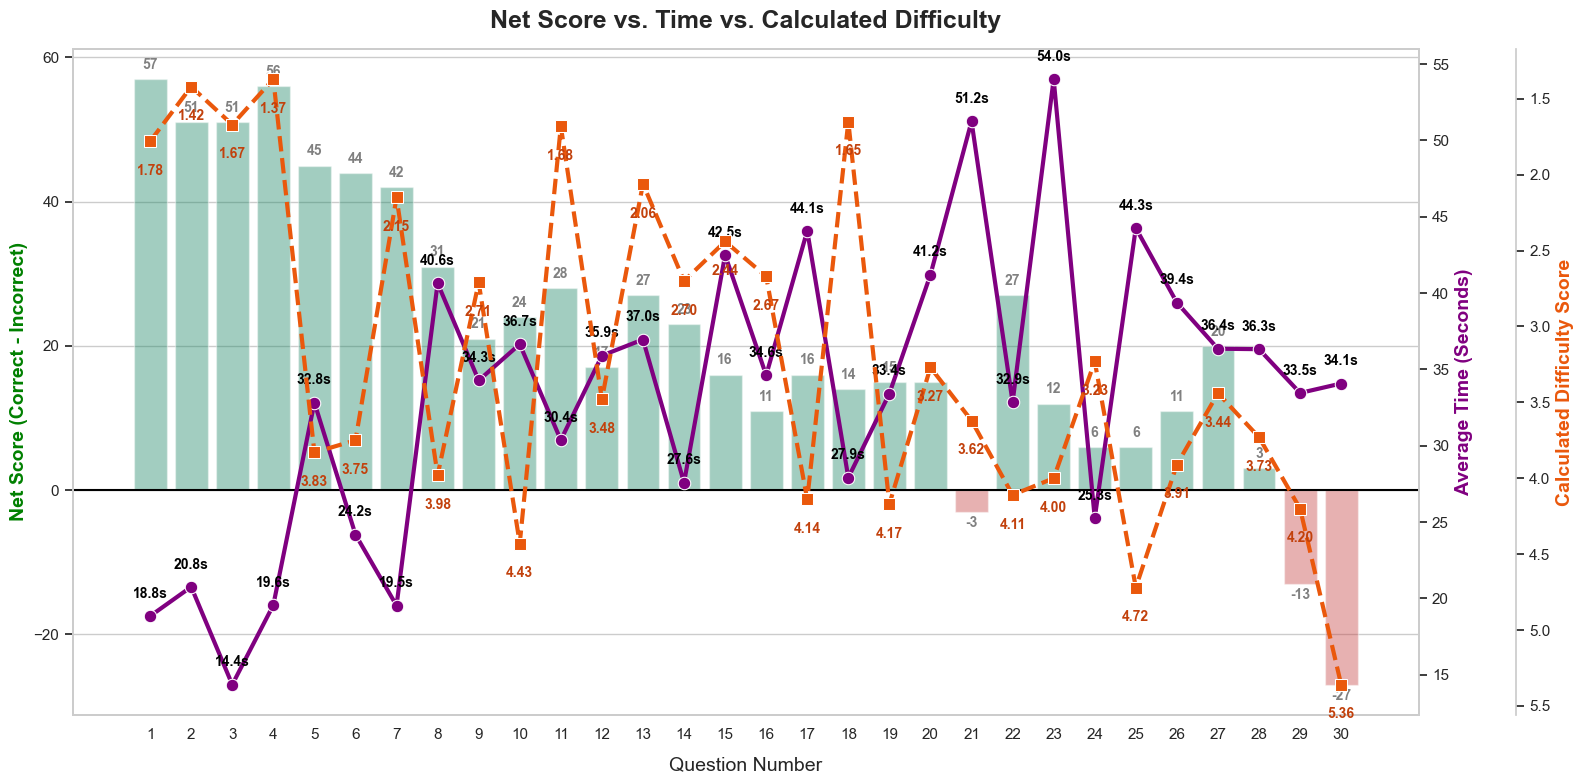

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare COMBINED Time Data (Exclude Skips)
df_all_time = df_base[df_base['userAnswer'] != 'SKIPPED'].copy()
df_avg_time_all = df_all_time.groupby('questionNumber')['timeTakenSec'].mean().reset_index()

# 2. Prepare COMBINED Score Data (Skips = Incorrect)
df_all_score = df_base.copy()
df_all_score.loc[df_all_score['userAnswer'] == 'SKIPPED', 'isCorrect'] = False
df_all_score['isCorrect'] = df_all_score['isCorrect'].astype(bool)
df_all_score['score_weight'] = np.where(df_all_score['isCorrect'] == True, 1, -1)

df_net_score_all = df_all_score.groupby('questionNumber')['score_weight'].sum().reset_index()

# 3. Merge for Graphing
df_combined_all = pd.merge(df_avg_time_all, df_net_score_all, on='questionNumber')
df_combined_all = df_combined_all.sort_values('questionNumber').reset_index(drop=True)

# 4. Add your Calculated Difficulty Ratings
difficulty_ratings = [
    1.78, 1.42, 1.67, 1.37, 3.83, 3.75, 2.15, 3.98, 2.71, 4.43, 
    1.68, 3.48, 2.06, 2.70, 2.44, 2.67, 4.14, 1.65, 4.17, 3.27, 
    3.62, 4.11, 4.00, 3.23, 4.72, 3.91, 3.44, 3.73, 4.20, 5.36
]
df_combined_all['difficulty_rating'] = difficulty_ratings

# 5. Plotting
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- AXIS 1: Bar Chart (Net Score) ---
bar_colors_all = np.where(df_combined_all['score_weight'] >= 0, '#059669', '#dc2626').tolist()

sns.barplot(
    data=df_combined_all,
    x='questionNumber',
    y='score_weight',
    hue='questionNumber',
    palette=bar_colors_all,
    alpha=0.4,
    ax=ax1,
    legend=False
)

ax1.set_ylabel("Net Score (Correct - Incorrect)", fontsize=14, fontweight='bold', color='green')
ax1.set_xlabel("Question Number", fontsize=14, labelpad=10)
ax1.axhline(0, color='black', linewidth=1.5)

for index, row in df_combined_all.iterrows():
    y_val = row['score_weight']
    offset = 1.0 if y_val >= 0 else -2.5 
    ax1.text(index, y_val + offset, f"{int(y_val)}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='grey')

# --- AXIS 2: Line Chart (Average Time) ---
ax2 = ax1.twinx()

sns.lineplot(
    data=df_combined_all, 
    x=df_combined_all.index, 
    y='timeTakenSec', 
    marker='o', 
    linewidth=3, 
    markersize=9,
    color='purple',
    ax=ax2
)

ax2.set_ylabel("Average Time (Seconds)", fontsize=14, fontweight='bold', color='purple')
ax2.grid(False)

for index, row in df_combined_all.iterrows():
    ax2.text(index, row['timeTakenSec'] + 1, 
             f"{row['timeTakenSec']:.1f}s", 
             ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

# --- AXIS 3: Line Chart (Calculated Difficulty) ---
ax3 = ax1.twinx()
# Shift the third axis 70 pixels to the right so it doesn't overlap the Time axis
ax3.spines['right'].set_position(('outward', 70)) 

sns.lineplot(
    data=df_combined_all, 
    x=df_combined_all.index, 
    y='difficulty_rating', 
    marker='s', # 's' = Square marker to easily distinguish from the time circles
    linewidth=3, 
    markersize=9,
    color='#ea580c', # Orange
    linestyle='--',  # Dashed line
    ax=ax3
)

ax3.set_ylabel("Calculated Difficulty Score", fontsize=14, fontweight='bold', color='#ea580c')
ax3.grid(False)
ax3.invert_yaxis()

for index, row in df_combined_all.iterrows():
    ax3.text(index, row['difficulty_rating'] + 0.15, 
             f"{row['difficulty_rating']:.2f}", 
             ha='center', va='top', fontsize=10, color='#c2410c', fontweight='bold')

plt.title("Net Score vs. Time vs. Calculated Difficulty", fontsize=18, fontweight='bold', pad=15)
fig.tight_layout() # Ensures the shifted third axis doesn't get clipped off the edge of the image
plt.show()

In [10]:
# --- TIMING METRICS (ALL COMBINED) ---
df_avg_sorted_all = df_avg_time_all.sort_values(by='timeTakenSec').reset_index(drop=True)

shortest_q_a = df_avg_sorted_all.iloc[0]
longest_q_a = df_avg_sorted_all.iloc[-1]
middle_idx_a = len(df_avg_sorted_all) // 2
middle_q_a = df_avg_sorted_all.iloc[middle_idx_a]
grand_avg_time_all = df_avg_sorted_all['timeTakenSec'].mean()

print("--- TIMING METRICS: ALL COMBINED (Excludes Skips) ---")
print(f"FASTEST Question: Q{int(shortest_q_a['questionNumber'])} ({shortest_q_a['timeTakenSec']:.1f} seconds)")
print(f"MIDDLE Question:  Q{int(middle_q_a['questionNumber'])} ({middle_q_a['timeTakenSec']:.1f} seconds)")
print(f"SLOWEST Question: Q{int(longest_q_a['questionNumber'])} ({longest_q_a['timeTakenSec']:.1f} seconds)")
print(f"GRAND AVERAGE:  {grand_avg_time_all:.1f} seconds per question\n")


# --- SCORING METRICS (ALL COMBINED) ---
df_accuracy_all = df_all_score.groupby('questionNumber')['isCorrect'].mean().reset_index()
df_accuracy_all['accuracy_pct'] = df_accuracy_all['isCorrect'] * 100

df_acc_sorted_all = df_accuracy_all.sort_values(by='accuracy_pct').reset_index(drop=True)

min_acc_a = df_acc_sorted_all['accuracy_pct'].min()
max_acc_a = df_acc_sorted_all['accuracy_pct'].max()

mid_idx_a = len(df_acc_sorted_all) // 2
mid_acc_a = df_acc_sorted_all.iloc[mid_idx_a]['accuracy_pct']

least_qs_a = df_acc_sorted_all[df_acc_sorted_all['accuracy_pct'] == min_acc_a]['questionNumber'].tolist()
most_qs_a = df_acc_sorted_all[df_acc_sorted_all['accuracy_pct'] == max_acc_a]['questionNumber'].tolist()
middle_qs_a = df_acc_sorted_all[df_acc_sorted_all['accuracy_pct'] == mid_acc_a]['questionNumber'].tolist()

def format_qs(q_list):
    return ", ".join([f"Q{int(q)}" for q in q_list])

print("--- SCORING METRICS: ALL COMBINED (Skips = Incorrect) ---")
print(f"MOST Correctly Answered:   {format_qs(most_qs_a)} ({max_acc_a:.1f}% accuracy)")
print(f"MIDDLE Correctly Answered: {format_qs(middle_qs_a)} ({mid_acc_a:.1f}% accuracy)")
print(f"LEAST Correctly Answered:  {format_qs(least_qs_a)} ({min_acc_a:.1f}% accuracy)")

--- TIMING METRICS: ALL COMBINED (Excludes Skips) ---
FASTEST Question: Q3 (14.4 seconds)
MIDDLE Question:  Q9 (34.3 seconds)
SLOWEST Question: Q23 (54.0 seconds)
GRAND AVERAGE:  33.4 seconds per question

--- SCORING METRICS: ALL COMBINED (Skips = Incorrect) ---
MOST Correctly Answered:   Q4 (91.2% accuracy)
MIDDLE Correctly Answered: Q9 (66.2% accuracy)
LEAST Correctly Answered:  Q30 (25.5% accuracy)
